In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("16-diabetes.csv")

| Column Name              | Description                                                   |
|---------------------------|---------------------------------------------------------------|
| Pregnancies               | Number of times pregnant                                      |
| Glucose                   | Plasma glucose concentration a 2 hours in an oral glucose tolerance test |
| BloodPressure             | Diastolic blood pressure (mm Hg)                              |
| SkinThickness             | Triceps skin fold thickness (mm)                               |
| Insulin                   | 2 Hour serum insulin (mu U/ml)                                 |
| BMI                        | Body mass index (weight in kg/(height in m)^2)                 |
| DiabetesPedigreeFunction  | Diabetes pedigree function                                     |
| Age                        | Age (years)                                                   |
| Outcome                   | Class variable (0 or 1) – 268 of 768 are 1, the others are 0   |

In [3]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [8]:
colums_value_count = ['Glucose','BloodPressure','SkinThickness', 'Insulin', 'BMI' ]

for col in colums_value_count:
    zero_count = (data[col]==0).sum()
    zero_perc = 100 * zero_count / len(data)
    print(f"{col}: {zero_count} %{zero_perc:.2f}")

Glucose: 5 %0.65
BloodPressure: 35 %4.56
SkinThickness: 227 %29.56
Insulin: 374 %48.70
BMI: 11 %1.43


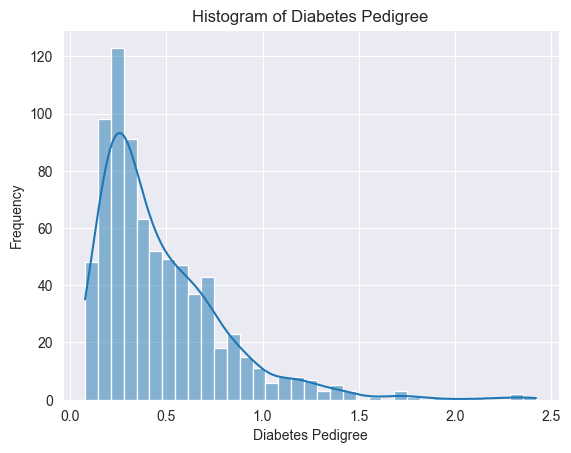

In [9]:
sns.histplot(data["DiabetesPedigreeFunction"], bins=35, kde=True)
plt.title("Histogram of Diabetes Pedigree")
plt.xlabel("Diabetes Pedigree")
plt.ylabel("Frequency")
plt.show()

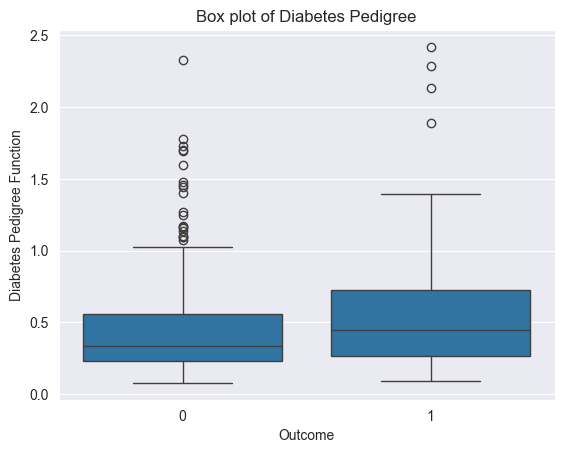

In [10]:
sns.boxplot(x="Outcome", y="DiabetesPedigreeFunction", data=data)
plt.title("Box plot of Diabetes Pedigree")
plt.xlabel("Outcome")
plt.ylabel("Diabetes Pedigree Function")
plt.show()

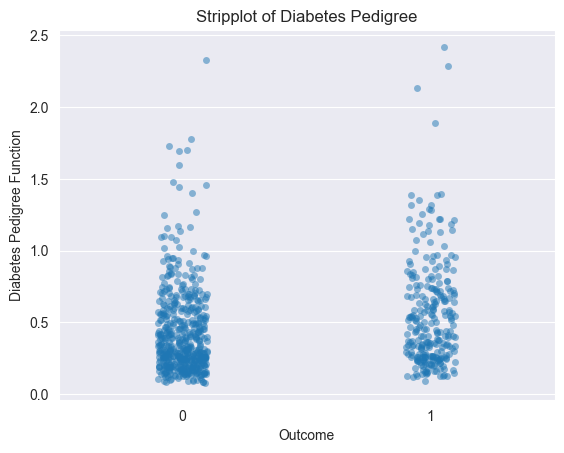

In [11]:
sns.stripplot(x="Outcome", y="DiabetesPedigreeFunction", data=data, jitter=True, alpha=0.5)
plt.title("Stripplot of Diabetes Pedigree")
plt.xlabel("Outcome")
plt.ylabel("Diabetes Pedigree Function")
plt.show()

In [12]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [14]:
columns_fill = ['Glucose','BloodPressure','SkinThickness', 'Insulin', 'BMI' ]

In [15]:
medians = {}

for col in columns_fill:
    mediansValue = X_train[X_train[col] !=0][col].median()
    medians[col] = mediansValue
    X_train[col] = X_train[col].replace(0, mediansValue)

for col in columns_fill:
    X_test[col] = X_test[col].replace(0, medians[col])

In [16]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.907166,121.560261,72.612378,29.040717,142.477199,32.448208,0.469948,33.285016
std,3.385438,29.974412,12.165642,8.312217,80.879330,6.862948,0.328516,11.678337
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.238250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.370500,29.000000
75%,6.000000,139.750000,80.000000,32.000000,130.000000,36.500000,0.630750,40.000000
max,17.000000,199.000000,122.000000,63.000000,680.000000,67.100000,2.420000,81.000000


In [17]:
X_test.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,3.597403,122.038961,71.487013,29.376623,144.402597,32.483117,0.479565,33.064935
std,3.304818,32.320876,11.813495,10.513035,104.291511,6.946159,0.343303,12.118519
min,0.000000,61.000000,30.000000,7.000000,23.000000,18.400000,0.078000,21.000000
25%,1.000000,95.250000,64.000000,23.250000,108.250000,26.925000,0.254000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.376500,28.000000
75%,5.750000,142.750000,80.000000,33.750000,129.500000,36.950000,0.603750,41.000000
max,13.000000,197.000000,106.000000,99.000000,846.000000,55.000000,2.329000,69.000000


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [20]:
adaBoost = AdaBoostClassifier()

adaBoost.fit(X_train, y_train)
y_pred = adaBoost.predict(X_test)

In [22]:
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7532467532467533
[[87 21]
 [17 29]]
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154



In [23]:
# hyperparameter tuning

In [24]:
from sklearn.model_selection import GridSearchCV

In [28]:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html

param = {
    "n_estimators": [50, 70, 100, 120, 150, 200],
    "learning_rate": [1, 10, 0.1, 0.01, 0.001],
}

In [34]:
grid = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=param, cv = 5, verbose=1, n_jobs=-1)

In [35]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,AdaBoostClassifier()
,param_grid,"{'learning_rate': [1, 10, ...], 'n_estimators': [50, 70, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [36]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 150}

In [37]:
adaBoost = AdaBoostClassifier(learning_rate=1, n_estimators=150)

In [38]:
adaBoost.fit(X_train, y_train)
y_pred = adaBoost.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7597402597402597
[[87 21]
 [16 30]]
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.59      0.65      0.62        46

    accuracy                           0.76       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.77      0.76      0.76       154



In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [40]:
def calculate_model_metrics(true, predicted):
    confusionMatrix = confusion_matrix(true, predicted)
    accuracy = accuracy_score(true, predicted)
    classificationReport = classification_report(true, predicted)
    return  confusionMatrix,accuracy,classificationReport

In [41]:
models = {
    "LogisticRegression": LogisticRegression(),
    "SVM ": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
}

In [43]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_confusionMatrix, model_train_accuracy, model_train_classificationReport = calculate_model_metrics(y_train, y_train_pred)
    model_test_confusionMatrix, model_test_accuracy, model_test_classificationReport = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("Accuracy: ", model_train_accuracy)
    print("Confusion Matrix: \n", model_train_confusionMatrix)
    print("Classification Report :", model_train_classificationReport)

    print("------------------------")

    print("Evaluation for Test Set")
    print("Accuracy: ", model_test_accuracy)
    print("Confusion Matrix: \n", model_test_confusionMatrix)
    print("Classification Report:", model_test_classificationReport)

    print("------------------------")
    print("\n")

LogisticRegression()
Evaluation for Training Set
Accuracy:  0.7833876221498371
Confusion Matrix: 
 [[347  45]
 [ 88 134]]
Classification Report :               precision    recall  f1-score   support

           0       0.80      0.89      0.84       392
           1       0.75      0.60      0.67       222

    accuracy                           0.78       614
   macro avg       0.77      0.74      0.75       614
weighted avg       0.78      0.78      0.78       614

------------------------
Evaluation for Test Set
Accuracy:  0.7532467532467533
Confusion Matrix: 
 [[89 19]
 [19 27]]
Classification Report:               precision    recall  f1-score   support

           0       0.82      0.82      0.82       108
           1       0.59      0.59      0.59        46

    accuracy                           0.75       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.75      0.75      0.75       154

------------------------


SVC()
Evaluation for Training Se

In [49]:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

# hyperparameter tuning

logistic_params = {
    "penalty": ["l1","l2","elasticnet"],
    "C": [100, 10, 1.0, 0.1, 0.01],
    "solver": ["newton_cg", "lbfgs", "liblinear", "sag", "saga", "newton-cholesky"]
}
svc_params = {
    "C": [0.1, 1, 10, 100, 1000],
    "kernel": ["rbf", "poly", "rbf", "sigmoid"],
    "gamma": ["scale", "auto"]
}

# There is no need for hyperparameter tuning in GausianNB because it does not have different parameters.

KNN_params = {
    "n_neighbors": [5, 10, 15, 20],
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"]
}

decisionTree_params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [1,2,3,4,5,15, None],
    "max_features": ["sqrt", "log2", None],
}

randomForest_params = {
    "max_depth": [5,8,10,15,None],
    "max_features": ["sqrt","log2", 5, 7],
    "min_samples_split": [2, 8, 10],
    "n_estimators": [100, 200, 500]
}

In [54]:
from sklearn.model_selection import GridSearchCV

In [59]:
randomcv_models = [
    ("Logistic Regressor", LogisticRegression(), logistic_params),
    ("SVC", SVC(), svc_params),
    ("KNN", KNeighborsClassifier(), KNN_params),
    ("Decision Tree", DecisionTreeClassifier(), decisionTree_params),
    ("Random Forest", RandomForestClassifier(), randomForest_params),
]

In [60]:
import warnings
warnings.filterwarnings("ignore")

for name, model, params in randomcv_models:
    randomcv = GridSearchCV(estimator=model, param_grid=params, cv=3, n_jobs=-1, scoring="accuracy")
    randomcv.fit(X_train, y_train),
    print("Best Params for: ", name, randomcv.best_params_ )

Best Params for:  Logistic Regressor {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Params for:  SVC {'C': 0.1, 'gamma': 'scale', 'kernel': 'sigmoid'}
Best Params for:  KNN {'algorithm': 'auto', 'n_neighbors': 20, 'weights': 'uniform'}
Best Params for:  Decision Tree {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'splitter': 'best'}
Best Params for:  Random Forest {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}


In [61]:
models = {
    "LogisticRegression": LogisticRegression(C=0.1, penalty="l1", solver="liblinear"),
    "SVC": SVC(C=0.1, kernel="sigmoid", gamma="scale"),
    "KNN": KNeighborsClassifier(algorithm="auto", n_neighbors=20, weights="uniform"),
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_features=None, max_depth=5, splitter="best"),
    "Random Forest": RandomForestClassifier(max_depth=None, max_features="sqrt", n_estimators=100, min_samples_split=10)
}

In [62]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_confusionMatrix, model_train_accuracy, model_train_classificationReport = calculate_model_metrics(y_train, y_train_pred)
    model_test_confusionMatrix, model_test_accuracy, model_test_classificationReport = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("Accuracy: ", model_train_accuracy)
    print("Confusion Matrix: \n", model_train_confusionMatrix)
    print("Classification Report :", model_train_classificationReport)

    print("------------------------")

    print("Evaluation for Test Set")
    print("Accuracy: ", model_test_accuracy)
    print("Confusion Matrix: \n", model_test_confusionMatrix)
    print("Classification Report:", model_test_classificationReport)

    print("------------------------")
    print("\n")

LogisticRegression(C=0.1, penalty='l1', solver='liblinear')
Evaluation for Training Set
Accuracy:  0.7817589576547231
Confusion Matrix: 
 [[345  47]
 [ 87 135]]
Classification Report :               precision    recall  f1-score   support

           0       0.80      0.88      0.84       392
           1       0.74      0.61      0.67       222

    accuracy                           0.78       614
   macro avg       0.77      0.74      0.75       614
weighted avg       0.78      0.78      0.78       614

------------------------
Evaluation for Test Set
Accuracy:  0.7402597402597403
Confusion Matrix: 
 [[88 20]
 [20 26]]
Classification Report:               precision    recall  f1-score   support

           0       0.81      0.81      0.81       108
           1       0.57      0.57      0.57        46

    accuracy                           0.74       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.74      0.74      0.74       154

--------------------